# Assignment 8: PCA Beyond 2D — Reducing 3D Data to 2D

The first few assignments used 2D data where I could draw everything. This one steps up to 3D, which is still something I can visualize — but it makes clear how PCA naturally extends to any number of dimensions.

## Step 1: Create a Correlated 3D Dataset

I am generating 300 samples from a 3D Gaussian with strong off-diagonal correlations in the covariance matrix. All three features share underlying structure, so PCA should be able to compress them — the cloud is not truly 3D at heart.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

np.random.seed(42)

# 3D correlated Gaussian — strong correlation across all 3 features
mean = [0, 0, 0]
cov  = [[3.0, 2.2, 1.5],
        [2.2, 2.5, 1.8],
        [1.5, 1.8, 2.0]]

n = 300
X_raw = np.random.multivariate_normal(mean, cov, size=n)

# Store in a DataFrame for clarity
df = pd.DataFrame(X_raw, columns=['Feature_1', 'Feature_2', 'Feature_3'])

print(f"Dataset shape: {df.shape}")
print(f"\nDescriptive statistics:")
df.describe().round(3)

Dataset shape: (300, 3)

Descriptive statistics:


,Feature_1,Feature_2,Feature_3
count,300.000,300.000,300.000
mean,-0.144,-0.116,-0.012
std,1.564,1.420,1.350
min,-4.175,-4.354,-3.752
25%,-1.242,-1.047,-0.833
50%,-0.009,-0.060,0.107
75%,0.917,0.948,0.912
max,4.482,3.739,4.206


In [2]:
# Correlation matrix — shows how strongly features are related
print("Correlation Matrix:")
df.corr().round(3)

Correlation Matrix:


,Feature_1,Feature_2,Feature_3
Feature_1,1.000,0.762,0.546
Feature_2,0.762,1.000,0.758
Feature_3,0.546,0.758,1.000


## Step 2: Standardize and Apply PCA (3D → 2D)

Standardizing with sklearn's StandardScaler, then applying PCA with n_components=2. This keeps PC1 and PC2 and drops the third component — the one with the least variance.

In [3]:
# Standardize using sklearn StandardScaler
scaler   = StandardScaler()
X_scaled = scaler.fit_transform(df)

# Apply PCA: reduce 3D → 2D
pca      = PCA(n_components=2)
X_pca    = pca.fit_transform(X_scaled)

# Store projected data in a DataFrame
df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])

# Variance explained summary
evr = pca.explained_variance_ratio_
summary_df = pd.DataFrame({
    'Component'        : ['PC1', 'PC2'],
    'Lambda'           : pca.explained_variance_.round(4),
    'Explained_Var_%'  : (evr * 100).round(2),
    'Cumulative_%'     : (np.cumsum(evr) * 100).round(2)
}).set_index('Component')

print("PCA Summary (3D → 2D):")
print(summary_df.to_string())
print(f"\nTotal variance retained: {evr.sum()*100:.2f}%")
print(f"Variance lost (PC3 dropped): {(1 - evr.sum())*100:.2f}%")

PCA Summary (3D → 2D):
           Lambda  Explained_Var_%  Cumulative_%
Component                                       
PC1        2.3902            79.41         79.41
PC2        0.4551            15.12         94.52

Total variance retained: 94.52%
Variance lost (PC3 dropped): 5.48%


In [4]:
# PC loadings table — how much each original feature contributes to each PC
loadings_df = pd.DataFrame(
    pca.components_.T,
    index=df.columns,
    columns=['PC1_Loading', 'PC2_Loading']
).round(4)

print("PC Loadings (contribution of each feature to each PC):")
loadings_df

PC Loadings (contribution of each feature to each PC):


,PC1_Loading,PC2_Loading
Feature_1,0.5587,-0.7038
Feature_2,0.6138,-0.0047
Feature_3,0.5577,0.7103


## Step 3: Look at the 3D Cloud First

Before seeing the compressed version, I want to look at the original 3D space. I am coloring each point by its PC1 score — that way the link between the 3D structure and the PCA compression is visually obvious.

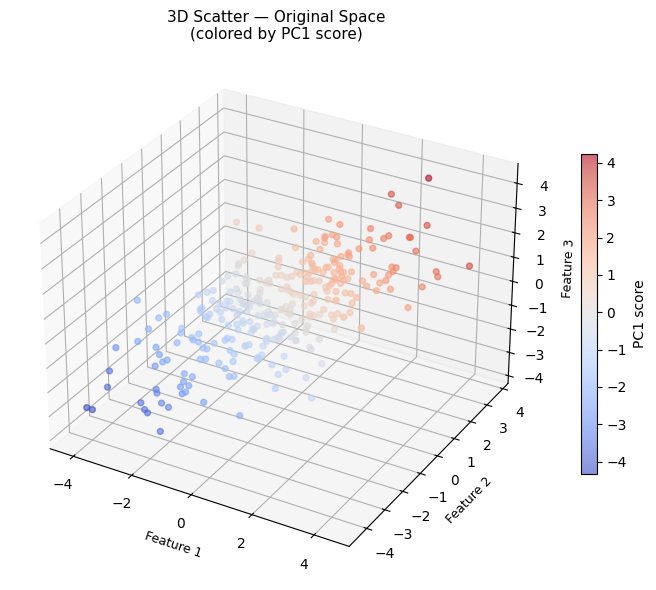

In [5]:
fig = plt.figure(figsize=(8, 6))
ax  = fig.add_subplot(111, projection='3d')

scatter = ax.scatter(
    df['Feature_1'], df['Feature_2'], df['Feature_3'],
    c=df_pca['PC1'],          # color by PC1 score to link both plots visually
    cmap='coolwarm', alpha=0.6, s=18
)
plt.colorbar(scatter, ax=ax, label='PC1 score', shrink=0.6)

ax.set_xlabel('Feature 1', fontsize=9)
ax.set_ylabel('Feature 2', fontsize=9)
ax.set_zlabel('Feature 3', fontsize=9)
ax.set_title('3D Scatter — Original Space\n(colored by PC1 score)', fontsize=11)

plt.tight_layout()
plt.savefig('../output/pca_assignment_8_3d_scatter.png', dpi=150, bbox_inches='tight')
plt.show()

## Step 4: The Same Data in 2D PCA Space

Now the same points plotted in the compressed coordinate system. The variance percentages on each axis label tell me exactly how much of the original 3D information is captured here.

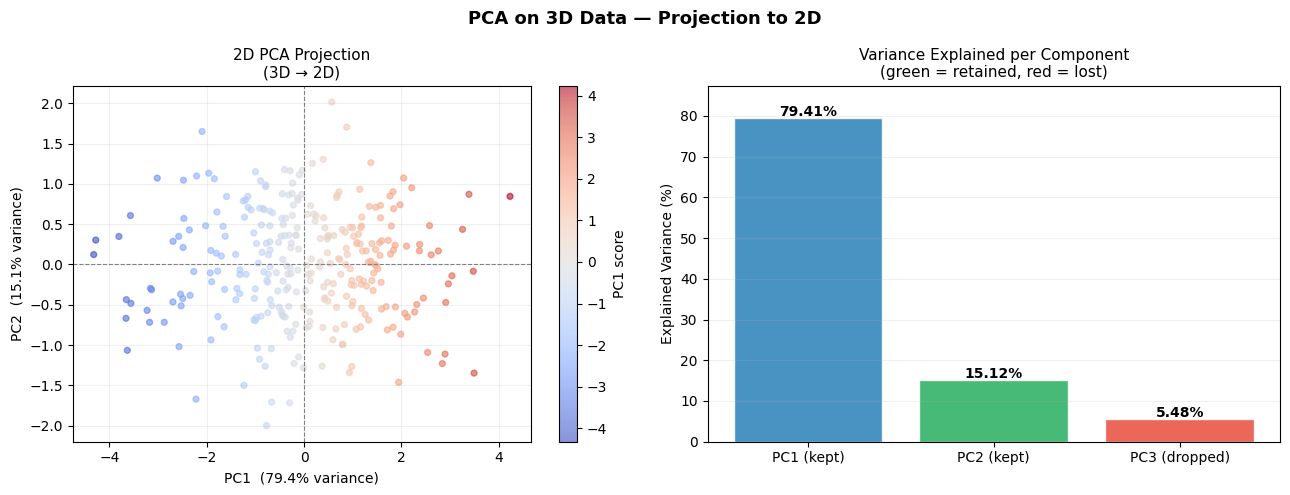

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Left: 2D PCA scatter ──────────────────────────────────────────────────────
ax = axes[0]
sc = ax.scatter(
    df_pca['PC1'], df_pca['PC2'],
    c=df_pca['PC1'], cmap='coolwarm', alpha=0.6, s=18
)
plt.colorbar(sc, ax=ax, label='PC1 score')
ax.axhline(0, color='gray', lw=0.8, ls='--')
ax.axvline(0, color='gray', lw=0.8, ls='--')
ax.set_xlabel(f"PC1  ({evr[0]*100:.1f}% variance)", fontsize=10)
ax.set_ylabel(f"PC2  ({evr[1]*100:.1f}% variance)", fontsize=10)
ax.set_title('2D PCA Projection\n(3D → 2D)', fontsize=11)
ax.grid(True, alpha=0.2)

# ── Right: Explained variance bar chart ──────────────────────────────────────
ax = axes[1]
all_evr = np.append(evr, 1 - evr.sum())          # include dropped PC3
pc_labels = ['PC1 (kept)', 'PC2 (kept)', 'PC3 (dropped)']
bar_colors = ['#2980b9', '#27ae60', '#e74c3c']
bars = ax.bar(pc_labels, all_evr * 100, color=bar_colors, alpha=0.85, edgecolor='white')

for bar, val in zip(bars, all_evr * 100):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
            f'{val:.2f}%', ha='center', fontsize=10, fontweight='bold')

ax.set_ylabel('Explained Variance (%)')
ax.set_title('Variance Explained per Component\n(green = retained, red = lost)', fontsize=11)
ax.set_ylim(0, max(all_evr * 100) + 8)
ax.grid(True, alpha=0.2, axis='y')

plt.suptitle('PCA on 3D Data — Projection to 2D', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../output/pca_assignment_8_2d_projection.png', dpi=150, bbox_inches='tight')
plt.show()